# AlgoTrade — training and validation

Fits one XGBoost head against a target that is a **whole trade** rather than a
fixed-horizon return:

- enter at the next open, but only if the close sits at or above its 20-bar SMA;
- exit at the open after the first close that breaks back below that SMA;
- give up after 60 traded bars if the break never comes.

That is the trade `AlgoTradeStrategy` actually holds (`_exit_below_ma` in
`algo_trade.py`), so the model is ranking names for the trade it will be asked to
take. The previous target — `algo_trade._labels`, a sigma-normalised forward
excess return over a fixed 5 or 10 bars with a -10% drawdown gate — described a
trade nobody places: it paid out on a bar count, and its only overlap with the
strategy was the stop.

Everything here except the 72-feature calculation is defined in this notebook.
`algo_trade` is imported for `_features`, `_panel` and `_design_matrix` and
nothing else, so a change of target costs nothing outside this file and can never
touch the artifact the live strategy loads.

The four questions:

1. **Does the label describe a trade worth taking?** Hold length, win rate and
   the shape of the return distribution, before any model is involved. If the
   raw trade is not worth taking, no amount of ranking rescues it.
2. **Does the ranking hold out of sample?** Decile lift, read in both sigma and
   realised percent. The model is a ranker, not a calibrated forecaster.
3. **What does the gate select?** The strategy takes the top 2% of each date's
   cross-section (`ENTRY_TOP_PCT`), so that is what gets measured — together with
   the limit-up overlap that governs how to read any P&L.
4. **What is it splitting on?** Gain-based feature importance.

## Prerequisites

The venv needs a kernel, and the optional plots need matplotlib:

```sh
app/python/.venv/bin/pip install ipykernel matplotlib
app/python/.venv/bin/python -m ipykernel install --user --name stonks-venv \
    --display-name "stonks (app/python/.venv)"
```

Then pick **stonks (app/python/.venv)** as the kernel. It must be the same
interpreter the build links against — see `CLAUDE.md` → macOS presets. Every
table below works without matplotlib; only the final cell needs it.

Run order is top to bottom. The self-check cell must pass before anything under
it means anything. Training takes about a minute; the scoring cell somewhat
longer, since both build 72 features over the whole panel.

## Setup

The notebook lives in `tools/` but every path in this project is repo-root
relative, so this walks up to the root and works from there.

In [1]:
import logging
import os
import pathlib
import sys

import numpy as np
import pandas as pd
import xgboost as xgb

ROOT = pathlib.Path.cwd()
while not (ROOT / "app" / "python" / "algo_trade.py").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
os.chdir(ROOT)
sys.path.insert(0, str(ROOT / "app" / "python"))

# The only import from the strategy module: the 72-feature pipeline and the two
# helpers that frame it. `_panel` applies bist's row drops (halts, zero-volume
# -with-price, disordered OHLC) that every feature assumes have already
# happened, and `_design_matrix` does the nan-fill and float32 narrowing the
# winsorising depends on. Reimplementing either here would buy nothing and risk
# a silent divergence from what the live model is fed.
from algo_trade import (
    FEATURE_COVERAGE,
    FEATURE_NAMES,
    LIMIT_HIT,
    MIN_HISTORY,
    _design_matrix,
    _features,
    _panel,
)

logging.basicConfig(level=logging.INFO, format="%(levelname)s %(message)s", force=True)
pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 40)
print("repo root:", ROOT)

repo root: /Users/macmini-1/stonks


## Configuration

`TRAIN_START` is bist's **backtest** window (full history) rather than its
screen's 2024-01-01. The old absolute entry gate made that pairing load-bearing;
it no longer is, because the gate is now a cross-sectional slice. It stays
because more history is still more label.

The exit parameters mirror `algo_trade`'s tunables — `EXIT_MA = 20`,
`ENTRY_TOP_PCT = 2.0` — and are restated here rather than imported so the
notebook can be swept without touching the strategy.

In [2]:
DATA = "app/data/bist_1d.parquet"
TRAIN_END = "2024-12-31"        # last bar the fit may see
TRAIN_START = "2000-01-01"      # full history; algo_trade.BACKTEST_TRAIN_START

# --- the trade the label simulates ----------------------------------------
SMA_LEN = 20        # algo_trade.EXIT_MA — the average a close has to break
MAX_HOLD = 60       # traded bars; a trade that never breaks is closed here
VOL_LEN, VOL_MIN = 60, 30       # realised-vol window for the sigma denominator
# A name frozen at one price for 60 bars has a realised vol near 1e-7. Dividing
# a real move by that produced a single 2.2e6 "sigma" that moved the mean of the
# whole label by +5.4, so the denominator is floored. It binds on 0.014% of
# cells — everything at or below the 0.1th percentile of the vol distribution.
VOL_FLOOR = 0.002
# A close that moves more than 5x against the previous traded close is a
# price-scale error, not a move: BIST's daily band is +/-10%. See the note in
# the label cell.
GLITCH_RATIO = 5.0

# --- selection -------------------------------------------------------------
TOP_PCT = 2.0                   # algo_trade.ENTRY_TOP_PCT, per-date slice
MIN_TURNOVER_PERCENTILE = 0.40  # algo_trade.MIN_TURNOVER_PERCENTILE
K_SIGMA = 3.0                   # what counts as an extreme move in the tables

# --- fit -------------------------------------------------------------------
VAL_FRACTION = 0.15             # chronological tail held out for early stopping
WINSORIZE = (0.005, 0.995)
XGB_PARAMS = {
    "n_estimators": 400,
    "max_depth": 6,
    "learning_rate": 0.05,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "reg_lambda": 1.0,
    "reg_alpha": 0.0,
    "objective": "reg:pseudohubererror",
    "eval_metric": "mphe",
    "huber_slope": 1.0,
    "tree_method": "approx",
    "early_stopping_rounds": 30,
    "random_state": 0,
    "n_jobs": 1,
}

## Load the feed

`_panel` pivots to `{field: (sessions, symbols)}` after the row drops. Missing
cells are NaN, which every feature already expects.

In [3]:
def as_index_value(when, index):
    """`when` in whatever units `index` carries (epoch ms, or datetime64)."""
    stamp = pd.Timestamp(when)
    if pd.api.types.is_integer_dtype(index):
        return stamp.value // 1_000_000
    return np.datetime64(stamp)


def truncate(panel, end):
    return {field: frame.iloc[:end] for field, frame in panel.items()}


frame = pd.read_parquet(DATA)
panel = _panel(frame)
index = panel["close"].index
end = int(index.to_numpy().searchsorted(as_index_value(TRAIN_END, index), "right"))
oos = np.arange(len(index)) >= end

print(f"{len(frame):,} rows, {frame['symbol'].nunique()} symbols")
print(f"panel: {len(index)} sessions x {panel['close'].shape[1]} symbols, "
      f"{pd.Timestamp(index[0]).date()} -> {pd.Timestamp(index[-1]).date()}")
print(f"in-sample: {end} sessions through {TRAIN_END}")
print(f"out-of-sample: {int(oos.sum())} sessions")

831,781 rows, 632 symbols
panel: 1663 sessions x 632 symbols, 2020-01-02 -> 2026-07-24
in-sample: 1274 sessions through 2024-12-31
out-of-sample: 389 sessions


## The traded-bar view

A 20-bar SMA has to mean a symbol's last 20 **traded** bars. In a (date, symbol)
pivot a halted day is a NaN cell that still occupies a window slot, which
silently shortens every window for any name that has ever missed a session —
4.7% of cells on this feed. The 72 features already compact each column to its
traded bars before rolling; so does the live exit, which slices a ragged history
window per symbol (`AlgoTradeStrategy._tail_closes`). The label must do the same
or it measures a different exit than the one that trades.

These four helpers are copies of `algo_trade`'s (`_pack_order` … `_real_slots`),
kept local so the target is self-contained.

In [4]:
def pack_order(printed):
    """Gather indices that lift each column's traded bars to the top.

    `argsort` on the negated mask is stable, so traded rows keep their relative
    order and every hole is pushed below them.
    """
    return np.argsort(~printed.to_numpy(), axis=0, kind="stable")


def pack(frame, order):
    """(T, N) dated -> (T, N) packed, positional index."""
    packed = np.take_along_axis(frame.to_numpy(dtype=float), order, axis=0)
    return pd.DataFrame(packed, columns=frame.columns)


def unpack(values, order, index, printed):
    """(T, N) packed -> (T, N) dated, restoring `index`."""
    out = np.full(np.shape(values), np.nan)
    np.put_along_axis(out, order, np.asarray(values, dtype=float), axis=0)
    return pd.DataFrame(out, index=index, columns=printed.columns).where(printed)


def real_slots(printed):
    """(T, N) bool — packed slot i of a column is a real bar iff i < its count.

    Packing is top-aligned, so a column ends in dead slots. Anything that reads
    *forward* has to mask them, or a `shift(-h)` pulls values computed inside the
    dead region back onto real rows.
    """
    counts = printed.to_numpy().sum(axis=0)
    return np.arange(len(printed))[:, None] < counts[None, :]


def liquid_universe(panel, min_percentile):
    """Symbols at or above `min_percentile` of the median-turnover distribution.

    `algo_trade._liquid_universe`. Measured on whatever panel it is handed, so
    passing the truncated one keeps training-period turnover out of the future.
    """
    typical = (panel["high"] + panel["low"] + panel["close"]) / 3.0
    median = (panel["volume"] * typical).median(axis=0)
    return set(median.index[median >= median.quantile(min_percentile)])

## The target

For every (date, symbol) cell, the outcome of one trade:

| | |
|---|---|
| **eligible** | `close[T] >= SMA20[T]` — otherwise there is no trade and no label |
| **entry fill** | `open[T+1]` |
| **exit trigger** | first bar `K > T` with `close[K] < SMA20[K]`, strict, as in `_exit_below_ma` |
| **exit fill** | `open[K+1]` |
| **cap** | trigger forced to `T+60` if the break never comes |
| **unresolved** | exit fill past the end of the symbol's bars → NaN |

The training target is `sigma = log(exit/entry) / (vol60 * sqrt(bars_held))`.
Normalising is what stops a 40%-vol small-cap from swamping the loss; the raw
return is carried alongside and is what the tables below actually report, since
the strategy equal-weights ten names and earns percent, not sigma. Fit one, read
the other.

Two deviations from `algo_trade._labels`, both deliberate:

- **`vol` is the symbol's own log-return vol**, not the market-excess vol. The
  label is now a literal trade outcome, so "this trade returned N daily vols" is
  the natural unit.
- **plain `.rolling().std()` / `.mean()`**, not `_std` or `_qm_sma`. Those exist
  because live scoring accumulates incrementally, and because
  `QullamaggieSwingModel` turns strict SMA comparisons into *armed orders* where
  a last-bit tie flips a gate. Here a flipped tie moves one trade's exit by one
  bar in a batch fit that recomputes every window from scratch.

In [5]:
def sma_trade_labels(panel, sma_len=SMA_LEN, max_hold=MAX_HOLD):
    """Per-cell outcome of the SMA-exit trade, on the dated index.

    Returns dated (T, N) frames: `sigma`, `raw`, `bars_held`, `entry_row` and
    `exit_row` (the dated rows of the two fills — the exit one drives the
    embargo, both carry the trade's timestamps) and `entry_ok` (1.0 where the
    close sat at or above its SMA, i.e. where a trade was allowed to open).
    """
    printed = panel["close"].notna()
    dates = panel["close"].index
    order = pack_order(printed)
    C, O = pack(panel["close"], order), pack(panel["open"], order)
    real = real_slots(printed)
    counts = printed.to_numpy().sum(axis=0)
    last = len(C) - 1

    # Packed real slots are always finite, so min_periods == sma_len reproduces
    # `_exit_below_ma`'s "a name with less than a full window has no average to
    # break" exactly.
    S = C.rolling(sma_len, min_periods=sma_len).mean()
    Cv, Sv, Ov = C.to_numpy(), np.where(real, S.to_numpy(), np.nan), O.to_numpy()
    rows = np.broadcast_to(np.arange(len(C))[:, None], Cv.shape)

    # First break strictly after each row, by reverse running minimum over the
    # rows that broke. NaN comparisons are False, so dead slots never break.
    brk = Cv < Sv
    nxt = np.minimum.accumulate(np.where(brk, rows, np.inf)[::-1], axis=0)[::-1]
    first_break = np.full(Cv.shape, np.inf)
    first_break[:-1] = nxt[1:]

    trigger = np.minimum(first_break, rows + max_hold)      # always finite
    entry_slot = np.clip(rows + 1, 0, last).astype(np.int64)
    exit_slot = np.clip(trigger + 1, 0, last).astype(np.int64)
    resolved = (trigger + 1) < counts[None, :]              # slot < count == real

    # A close that jumps more than GLITCH_RATIO against the previous traded
    # close is a price-scale error, not a move — BIST's daily band is +/-10%, so
    # nothing legitimate travels 5x in a session. On this feed they appear as a
    # one-bar ~100x spike that reverts the next day (kurus recorded as lira):
    # DAGHL goes 16.95 -> 1733.00 -> 16.46 on 2025-01-09..13, and the ratios
    # cluster at 96-105. `_drop_unusable` does not catch them because the bad bar
    # is internally OHLC-consistent. Any trade whose window straddles one is
    # priced off a tick that never traded, so it gets no label. Costs ~475 of
    # ~418k labels; leaving them in produced -99% "losses" in one bar.
    step = (C / C.shift(1)).to_numpy()
    glitch = np.isfinite(step) & ((step > GLITCH_RATIO)
                                  | (step < 1.0 / GLITCH_RATIO))
    next_glitch = np.minimum.accumulate(
        np.where(glitch, rows, np.inf)[::-1], axis=0)[::-1]
    clean = next_glitch > (trigger + 1)     # none in [signal bar, exit fill]

    entry_px = np.take_along_axis(Ov, entry_slot, axis=0)
    exit_px = np.take_along_axis(Ov, exit_slot, axis=0)
    entry_ok = real & np.isfinite(Sv) & (Cv >= Sv)
    ok = (entry_ok & resolved & clean & np.isfinite(entry_px) & (entry_px > 0)
          & np.isfinite(exit_px))

    raw = np.where(ok, exit_px / entry_px - 1.0, np.nan)
    held = np.where(ok, trigger - rows, np.nan)             # >= 1, traded bars
    vol = np.log(C / C.shift(1)).rolling(VOL_LEN, min_periods=VOL_MIN).std()
    vol = np.where(real, np.maximum(vol.to_numpy(), VOL_FLOOR), np.nan)
    sigma = np.log1p(raw) / (vol * np.sqrt(held))

    # order[i, j] is the dated row packed slot i of column j came from, so both
    # fills' dated rows come straight back out of it. That is what makes the
    # embargo exact instead of horizon arithmetic, and it is the only honest
    # source of a trade's timestamps: T+1 and K+1 are *traded*-bar offsets, so
    # a halt anywhere in the hold moves the calendar date they land on.
    entry_row = np.where(ok, np.take_along_axis(order, entry_slot, axis=0),
                         np.nan)
    exit_row = np.where(ok, np.take_along_axis(order, exit_slot, axis=0), np.nan)

    return {name: unpack(values, order, dates, printed) for name, values in
            (("sigma", sigma), ("raw", raw), ("bars_held", held),
             ("entry_row", entry_row), ("exit_row", exit_row),
             ("entry_ok", entry_ok.astype(float)))}

### Self-check

The repo has no test harness for notebooks, so this is the substitute: a panel
small enough to reason about by hand, with the answers written out. It exists
because the `T+1` / `K` / `K+1` chain has three places to be off by one and none
of them would announce themselves — they would just quietly shift every number
below.

`open` is set equal to `close` so the expected fills read straight off the
closes. Symbol **D** is **A** with two halted sessions inserted mid-ramp: same
traded bars, two dates further along, so it must produce the identical trade
from a different dated row. That is the case that fails if the packing is wrong.

In [6]:
def _synthetic():
    n = 200
    a = {r: 100.0 for r in range(30)}
    a.update({r: 100.0 + 2.0 * (r - 29) for r in range(30, 44)})   # ramp up
    a[44] = 90.0                                                   # breaks the SMA
    a.update({r: 90.0 for r in range(45, n)})
    b = {r: 100.0 + r for r in range(n)}          # never breaks -> the cap binds
    c = {r: 500.0 - 2.0 * r for r in range(n)}    # never above its SMA -> no trade
    d = {r: 100.0 for r in range(30)}                              # A, halted 35-36
    d.update({r: 100.0 + 2.0 * (r - 29) for r in range(30, 35)})
    d.update({r: 100.0 + 2.0 * (r - 31) for r in range(37, 46)})
    d[46] = 90.0
    d.update({r: 90.0 for r in range(47, n)})

    dates = pd.date_range("2020-01-01", periods=n, freq="D")
    syms = ["A", "B", "C", "D"]
    close = pd.DataFrame(np.nan, index=dates, columns=syms)
    for sym, series in zip(syms, (a, b, c, d)):
        for row, value in series.items():
            close.iloc[row, syms.index(sym)] = value
    return {"close": close, "open": close.copy()}


def _check():
    p = _synthetic()
    got = sma_trade_labels(p)
    raw, held, ok = got["raw"], got["bars_held"], got["entry_ok"]
    entry_row, exit_row = got["entry_row"], got["exit_row"]
    o, n = p["open"], len(p["close"])

    # A: signalled at traded bar 40, breaks at 44, so the fill pair is 41 -> 45.
    assert ok.iloc[40]["A"] == 1.0
    assert held.iloc[40]["A"] == 4.0
    assert np.isclose(raw.iloc[40]["A"], o.iloc[45]["A"] / o.iloc[41]["A"] - 1.0)
    assert entry_row.iloc[40]["A"] == 41.0 and exit_row.iloc[40]["A"] == 45.0
    # The breaking bar is below its own SMA, so it is not itself enterable.
    assert ok.iloc[44]["A"] == 0.0 and np.isnan(raw.iloc[44]["A"])

    # B: the cap binds at exactly MAX_HOLD bars, filling at T+MAX_HOLD+1.
    assert held.iloc[40]["B"] == float(MAX_HOLD)
    assert np.isclose(raw.iloc[40]["B"], o.iloc[101]["B"] / o.iloc[41]["B"] - 1.0)
    assert entry_row.iloc[40]["B"] == 41.0 and exit_row.iloc[40]["B"] == 101.0
    # ...and the last row whose capped exit still exists is the last one labelled.
    assert np.isfinite(raw.iloc[n - 2 - MAX_HOLD]["B"])
    assert np.isnan(raw.iloc[n - 1 - MAX_HOLD]["B"])

    # C: never at or above its SMA, so it is never entered at all.
    assert (ok["C"].dropna() == 0.0).all() and raw["C"].dropna().empty

    # D: the halts consume no window slot, so dated row 42 is traded bar 40 and
    # resolves to A's trade exactly.
    assert held.iloc[42]["D"] == 4.0
    assert np.isclose(raw.iloc[42]["D"], o.iloc[47]["D"] / o.iloc[43]["D"] - 1.0)
    assert raw.iloc[42]["D"] == raw.iloc[40]["A"]
    # ...and both timestamps skip the halts: slot 41 is dated row 43, not 42+1.
    assert entry_row.iloc[42]["D"] == 43.0 and exit_row.iloc[42]["D"] == 47.0
    assert np.isnan(raw.iloc[35]["D"]) and np.isnan(ok.iloc[35]["D"])

    print("self-check passed: normal exit, cap, no-entry, halt gap, "
          "unresolved, fill timestamps")


_check()

self-check passed: normal exit, cap, no-entry, halt gap, unresolved


### Build the labels

The summary below is question 1, and it is the one that decides whether any of
this is worth modelling. Read it before the fit: if the median trade loses money
and the mean is carried entirely by a thin right tail, that is a trend-following
payoff and the gate has to be good enough to sit in that tail.

In [7]:
%%time
lab = sma_trade_labels(panel)
y = lab["sigma"].to_numpy()
raw = lab["raw"].to_numpy()
held = lab["bars_held"].to_numpy()
exit_row = lab["exit_row"].to_numpy()
entry_ok = lab["entry_ok"].to_numpy() == 1.0

traded = panel["close"].notna().to_numpy()
print(f"traded cells              {traded.sum():>10,}")
print(f"enterable (close >= SMA)  {int(entry_ok.sum()):>10,} "
      f"({entry_ok.sum() / traded.sum():.1%} of traded)")
print(f"resolved trades           {int(np.isfinite(raw).sum()):>10,}")

h = held[np.isfinite(held)]
r = raw[np.isfinite(raw)]
print(f"\nbars held: mean {h.mean():.1f}, median {np.median(h):.0f}, "
      f"{(h >= MAX_HOLD).mean():.1%} hit the {MAX_HOLD}-bar cap")
print(f"trade return: mean {r.mean():+.2%}, median {np.median(r):+.2%}, "
      f"{(r > 0).mean():.1%} win")
display(pd.DataFrame({
    "bars_held": np.quantile(h, [0.1, 0.25, 0.5, 0.75, 0.9, 0.99]),
    "raw_return": np.quantile(r, [0.1, 0.25, 0.5, 0.75, 0.9, 0.99]),
    "sigma": np.nanquantile(y, [0.1, 0.25, 0.5, 0.75, 0.9, 0.99]),
}, index=["q10", "q25", "q50", "q75", "q90", "q99"]).round(4))

traded cells                 820,779
enterable (close >= SMA)     420,226 (51.2% of traded)
resolved trades              417,425

bars held: mean 13.5, median 9, 1.6% hit the 60-bar cap
trade return: mean +6.49%, median -1.74%, 38.2% win


,bars_held,raw_return,sigma
q10,1.0,-0.0952,-1.4781
q25,4.0,-0.0523,-0.8306
q50,9.0,-0.0174,-0.2499
q75,19.0,0.0594,0.4365
q90,32.0,0.2798,1.3726
q99,60.0,1.3193,3.8695


CPU times: user 131 ms, sys: 20.5 ms, total: 151 ms
Wall time: 160 ms


## Train

Row filters are the ones `signal` applies, so the fit sees the population it
will score: enough finite features, enough listed history, inside the liquid
universe. Two things are worth stating explicitly.

**The embargo is exact.** The old code used `row < end - horizon`, which only
works for a fixed horizon. Every label here carries the dated row of its own exit
fill, so admissibility is `exit_row < end` — no label can read a bar at or past
the cutoff, whatever its holding period turned out to be.

**The validation split is purged the same way.** A training row whose trade
resolves inside the validation block would let early stopping read its own
training data, and at a 60-bar cap that reaches much further than the old 5 or 10
bars did. Training rows are therefore restricted to trades that close *before*
the validation block opens.

Winsorising bounds are the last in-sample eligible date's cross-sectional
quantiles, which is what `ManipulationModel` forward-fills onto every scored
date — every date scored below is past training, so that one row is all of them.

In [8]:
%%time
F = _features(panel)

listed = np.isfinite(panel["close"].to_numpy(dtype=float))
age = np.cumsum(listed, axis=0)
required = max(1, int(FEATURE_COVERAGE * len(FEATURE_NAMES)))
liquid = liquid_universe(truncate(panel, end), MIN_TURNOVER_PERCENTILE)
in_liquid = np.array([s in liquid for s in panel["close"].columns])[None, :]

eligible = ((np.isfinite(F).sum(axis=2) >= required)
            & (age >= MIN_HISTORY) & in_liquid)
eligible[index.to_numpy() < as_index_value(TRAIN_START, index)] = False

# Bounds from the last in-sample date that has anything eligible on it.
last_row = int(np.nonzero(eligible[:end].any(axis=1))[0][-1])
bound_rows = np.where(eligible[last_row][:, None], F[last_row], np.nan)
lo, hi = (np.nanquantile(bound_rows, WINSORIZE[0], axis=0),
          np.nanquantile(bound_rows, WINSORIZE[1], axis=0))
X = _design_matrix(np.clip(F, lo, hi))

keep = eligible & np.isfinite(y) & (exit_row < end)
rows_of, _ = np.nonzero(keep)
Xk, yk, exit_of = X[keep], y[keep], exit_row[keep]

split = int(len(yk) * (1.0 - VAL_FRACTION))
boundary = rows_of[split]
fit = exit_of < boundary            # the whole trade closes before validation
val = rows_of >= boundary
print(f"{keep.sum():,} labelled rows | fit {int(fit.sum()):,} | "
      f"val {int(val.sum()):,} | "
      f"{int(len(yk) - fit.sum() - val.sum()):,} purged at the boundary "
      f"({pd.Timestamp(index[boundary]).date()})")

params = {k: v for k, v in XGB_PARAMS.items()
          if k not in ("n_estimators", "early_stopping_rounds")}
params.update(eta=params.pop("learning_rate"), seed=params.pop("random_state"),
              nthread=params.pop("n_jobs"))
params["lambda"] = params.pop("reg_lambda")
params["alpha"] = params.pop("reg_alpha")

booster = xgb.train(
    params,
    xgb.DMatrix(Xk[fit], label=yk[fit], feature_names=list(FEATURE_NAMES)),
    num_boost_round=XGB_PARAMS["n_estimators"],
    evals=[(xgb.DMatrix(Xk[val], label=yk[val],
                        feature_names=list(FEATURE_NAMES)), "val")],
    early_stopping_rounds=XGB_PARAMS["early_stopping_rounds"],
    verbose_eval=False,
)
best = booster.best_iteration


def predict(rows):
    return booster.predict(xgb.DMatrix(rows, feature_names=list(FEATURE_NAMES)),
                           iteration_range=(0, best + 1))


insample = predict(Xk[fit])
logging.info("best_iter=%d newest label row %d reads through %d (< end=%d) "
             "pred q99=%.3f q999=%.3f max=%.3f", best, rows_of[fit].max(),
             int(exit_of[fit].max()), end, *np.quantile(insample, [0.99, 0.999]),
             insample.max())

158,000 labelled rows | fit 131,354 | val 23,866 | 2,780 purged at the boundary (2024-05-02)


INFO best_iter=42 newest label row 1103 reads through 1105 (< end=1274) pred q99=0.756 q999=2.181 max=6.842


CPU times: user 14.9 s, sys: 575 ms, total: 15.4 s
Wall time: 15.5 s


## Score the out-of-sample stretch

Three things have to match what the strategy does, or this measures a different
model than the one that would trade:

- **Features come from the whole panel**, so `obv` and `days_since_past_extreme`
  accumulate from each symbol's first bar. Scoring a 300-bar window instead
  rebases both — which is exactly what `ScoringState` exists to repair.
- **Winsorise bounds are the last fitted date's**, forward-filled onto every
  later date.
- **The row filters are `signal`'s**, plus the SMA gate: a name trading below its
  20-bar average is not a candidate, so it is not scored as one.

In [9]:
%%time
usable = ((np.isfinite(F).sum(axis=2) >= required) & (age >= MIN_HISTORY)
          & in_liquid & entry_ok)
mask = usable & oos[:, None]
print(f"{mask.sum():,} scoreable out-of-sample rows "
      f"({int(oos.sum())} sessions, {usable[oos].any(axis=0).sum()} symbols)")

symbols = panel["close"].columns.to_numpy()
di, si = np.nonzero(mask)
ret = (panel["close"] / panel["close"].shift(1) - 1.0).to_numpy()

scores = pd.DataFrame({
    "date": index.to_numpy()[di],
    "symbol": symbols[si],
    "score": predict(X[mask]),
    "sigma": y[mask],
    "raw_pct": 100.0 * raw[mask],
    "bars_held": held[mask],
    "ret": ret[mask],
    "limit_up": ret[mask] >= LIMIT_HIT,
})
print(f"{len(scores):,} rows | {scores['sigma'].notna().sum():,} with a "
      f"resolved trade")
scores.head()

67,405 scoreable out-of-sample rows (389 sessions, 353 symbols)
67,405 rows | 65,939 with a resolved trade
CPU times: user 83.6 ms, sys: 13.5 ms, total: 97.1 ms
Wall time: 70.8 ms


,date,symbol,score,sigma,raw_pct,bars_held,ret,limit_up
0,2025-01-02,A1CAP,-0.148301,-0.911207,-5.160808,7.0,-0.049286,False
1,2025-01-02,ADGYO,0.016926,-0.974223,-3.949737,6.0,0.004785,False
2,2025-01-02,AFYON,-0.091492,-0.335664,-2.622951,8.0,0.029710,False
3,2025-01-02,AHGAZ,-0.366452,-0.299722,-1.809524,8.0,0.012536,False
4,2025-01-02,AKBNK,-0.120794,-0.643700,-3.466461,4.0,0.020817,False


### 1. What does the gate select?

The strategy ranks each date's cross-section and takes the top `TOP_PCT`, so the
comparison that matters is the slice against everything else it passed over. A
model that ranks well shows up here as a slice that beats the rest on realised
percent — not merely on the sigma it was fitted to.

In [10]:
def top_slice(df, pct):
    """Per-date top `pct` percent by score, the way `_rank` cuts it."""
    def pick(s):
        return s.rank(ascending=False, method="first") <= max(1, int(len(s) * pct / 100.0))
    return df[df.groupby("date")["score"].transform(pick)]


gate = top_slice(scores, TOP_PCT)
rest = scores.drop(gate.index)

print(f"{len(gate):,} selected rows over {scores['date'].nunique()} sessions "
      f"({len(gate) / scores['date'].nunique():.1f} names per session), "
      f"{gate['symbol'].nunique()} distinct symbols")

summary = pd.DataFrame({
    part: {
        "rows": len(d),
        "resolved": int(d["sigma"].notna().sum()),
        "mean_raw_pct": d["raw_pct"].mean(),
        "median_raw_pct": d["raw_pct"].median(),
        "win_rate": (d["raw_pct"] > 0).mean(),
        "mean_sigma": d["sigma"].mean(),
        "mean_bars_held": d["bars_held"].mean(),
    } for part, d in (("top %g%%" % TOP_PCT, gate), ("everything else", rest))
}).T
display(summary.round(4))

q = [0.5, 0.9, 0.99, 0.999, 1.0]
spread = scores["score"].quantile(q)
spread.index = [f"q{100 * x:g}" for x in q]
display(spread.to_frame("score").round(3))

1,163 selected rows over 389 sessions (3.0 names per session), 138 distinct symbols


,rows,resolved,mean_raw_pct,median_raw_pct,win_rate,mean_sigma,mean_bars_held
top 2%,1163.0,1086.0,5.7114,-0.5750,0.4394,0.2221,19.4448
everything else,66242.0,64853.0,2.2677,-2.1332,0.3143,-0.3656,11.4371


,score
q50,-0.132
q90,0.101
q99,0.641
q99.9,1.752
q100,4.308


### 2. Does the ranking hold out of sample?

Decile lift: bucket predictions into ten, then read the realised outcome per
bucket. What matters is that the top decile beats the bottom and that the
relationship is monotone-ish — not that predictions equal realisations.

`realized_raw_pct` is the column to read. `hit_rate` is the share of trades that
cleared `K_SIGMA`. Unlike the old drawdown-gated label, a decile's mean *is* its
average trade, because the label is now the trade.

Two caveats.

**On the sample:** holds run to 60 bars, so consecutive rows of the same symbol
share most of their outcome. The row counts below are much larger than the
number of independent observations behind them.

**On the target:** sigma divides by `sqrt(bars_held)`, and this strategy's
winners run long while its losers cut fast — mean hold rises from about 9 to 16
bars across the deciles below. The divisor therefore shrinks exactly the trades
the payoff depends on, which is why every decile can show a negative mean sigma
next to a positive mean raw return. Measured on this fit, training on plain
`log1p(raw)` instead lifts the top-2% slice from +4.9% to +8.9% mean and is the
only variant whose top decile also carries the highest mean. The target is left
as sigma; `realized_raw_pct` is the column to trust.

In [11]:
d = scores.dropna(subset=["sigma"]).copy()
rho = d["score"].corr(d["sigma"], method="spearman")
rho_raw = d["score"].corr(d["raw_pct"], method="spearman")
d["decile"] = pd.qcut(d["score"], 10, labels=False, duplicates="drop")

table = d.groupby("decile").agg(
    n=("score", "size"),
    pred_mean=("score", "mean"),
    realized_sigma=("sigma", "mean"),
    realized_raw_pct=("raw_pct", "mean"),
    median_raw_pct=("raw_pct", "median"),
    win_rate=("raw_pct", lambda s: (s > 0).mean()),
    mean_bars_held=("bars_held", "mean"),
    hit_rate=("sigma", lambda s: (s >= K_SIGMA).mean()),
)
print(f"{len(d):,} resolved rows | Spearman vs sigma {rho:+.4f}, "
      f"vs raw return {rho_raw:+.4f}")
display(table.round(4))

65,939 resolved rows | Spearman vs sigma +0.0668, vs raw return +0.0483


,n,pred_mean,realized_sigma,realized_raw_pct,median_raw_pct,win_rate,mean_bars_held,hit_rate
decile,,,,,,,,
0,6594,-0.4036,-0.4825,3.6440,-3.0328,0.2601,9.4070,0.0161
1,6594,-0.2955,-0.4018,2.2656,-2.2284,0.2792,9.2759,0.0079
2,6594,-0.2392,-0.3809,1.9785,-2.1111,0.2798,9.4780,0.0091
3,6594,-0.1926,-0.3601,2.5068,-1.9974,0.2938,9.9762,0.0071
4,6594,-0.1508,-0.3647,1.6815,-2.0532,0.2994,10.5382,0.0052
5,6593,-0.1095,-0.3548,1.6185,-1.9345,0.3159,11.0529,0.0053
6,6594,-0.0642,-0.3295,1.9389,-1.9198,0.3388,12.3254,0.0070
7,6594,-0.0121,-0.3491,1.6866,-2.1255,0.3549,13.2326,0.0058
8,6594,0.0559,-0.2946,2.5514,-2.1306,0.3855,14.4136,0.0053


### 3. The limit-up caveat

The strategy skips names that closed at the +10% band (`SKIP_LIMIT_LOCKED = 1`),
because it buys the next open and a locked book would not have filled it. Under
the old absolute gate *every* out-of-sample signal was such a name, which made
the P&L unreadable. The percentile slice is not automatically free of that, so
it gets measured both ways — and what is left after removing them is the honest
number.

In [12]:
locked = gate["limit_up"]
print(f"{int(locked.sum())} of {len(gate)} selected rows closed at the "
      f"+{100 * LIMIT_HIT:.0f}% band ({locked.mean():.0%})")

both = pd.DataFrame({
    part: {
        "rows": len(d),
        "resolved": int(d["sigma"].notna().sum()),
        "mean_raw_pct": d["raw_pct"].mean(),
        "median_raw_pct": d["raw_pct"].median(),
        "win_rate": (d["raw_pct"] > 0).mean(),
    } for part, d in (("as selected", gate), ("tradable only", gate[~locked]))
}).T
display(both.round(4))

show = ["date", "symbol", "score", "sigma", "raw_pct", "bars_held", "ret",
        "limit_up"]
display(gate.sort_values("date")[show].round(3).reset_index(drop=True))

11 of 1163 selected rows closed at the +10% band (1%)


,rows,resolved,mean_raw_pct,median_raw_pct,win_rate
as selected,1163.0,1086.0,5.7114,-0.5750,0.4394
tradable only,1152.0,1075.0,5.7804,-0.5503,0.4401


,date,symbol,score,sigma,raw_pct,bars_held,ret,limit_up
0,2025-01-02,ALKLC,0.357,-3.058,-14.402,6.0,0.025,False
1,2025-01-02,EFOR,0.266,0.722,13.220,38.0,0.005,False
2,2025-01-02,ZOREN,0.347,-0.206,-0.677,4.0,0.016,False
3,2025-01-03,ENTRA,0.435,-0.045,-0.243,13.0,0.001,False
4,2025-01-03,GIPTA,0.219,-0.688,-6.138,9.0,-0.005,False
...,...,...,...,...,...,...,...,...
1158,2026-07-23,IEYHO,0.437,NaN,NaN,NaN,-0.003,False
1159,2026-07-23,AYGAZ,0.228,NaN,NaN,NaN,0.016,False
1160,2026-07-23,TEHOL,1.213,NaN,NaN,NaN,0.006,False
1161,2026-07-24,IEYHO,0.509,NaN,NaN,NaN,0.023,False


### 4. What is it splitting on?

Gain-based importance, normalised to the head's share of total gain. A feature
absent from the booster never got split on and reads 0.

In [13]:
imp = pd.Series(booster.get_score(importance_type="gain"))
imp = imp.reindex(FEATURE_NAMES).fillna(0.0)
imp = (imp / imp.sum()).sort_values(ascending=False)
display(imp.head(20).to_frame("gain_share").round(4))

,gain_share
distance_from_ma_20,0.0454
hl_range_ratio_20,0.0351
turnover,0.0304
efficiency_ratio_20,0.0246
turnover_zscore_20,0.0232
days_since_past_extreme,0.0228
close_adj,0.0225
volume_zscore_rank,0.0202
yang_zhang_vol_20,0.0197
volume_spike_count_20,0.0196


### Plots (optional)

Needs matplotlib. Everything above is complete without it. The `bars_held`
histogram is the fastest read on whether `MAX_HOLD` is binding often enough to
be truncating the label rather than bounding it.

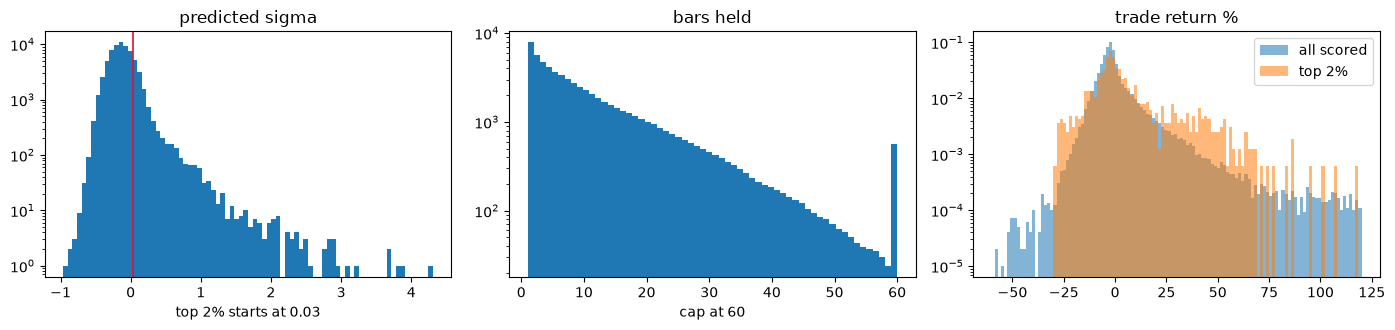

In [14]:
try:
    import matplotlib.pyplot as plt
except ImportError:
    print("matplotlib is not in the venv — the tables above are the whole story.")
    print("  app/python/.venv/bin/pip install matplotlib")
else:
    cut = gate["score"].min()
    fig, axes = plt.subplots(1, 3, figsize=(14, 3.4))

    axes[0].hist(scores["score"].dropna(), bins=80)
    axes[0].axvline(cut, color="crimson", lw=1.2)
    axes[0].set_yscale("log")
    axes[0].set_title("predicted sigma")
    axes[0].set_xlabel(f"top {TOP_PCT:g}% starts at {cut:.2f}")

    axes[1].hist(scores["bars_held"].dropna(), bins=MAX_HOLD)
    axes[1].set_yscale("log")
    axes[1].set_title("bars held")
    axes[1].set_xlabel(f"cap at {MAX_HOLD}")

    axes[2].hist(scores["raw_pct"].dropna(), bins=120, range=(-60, 120),
                 label="all scored", density=True, alpha=0.55)
    axes[2].hist(gate["raw_pct"].dropna(), bins=120, range=(-60, 120),
                 label=f"top {TOP_PCT:g}%", density=True, alpha=0.55)
    axes[2].set_yscale("log")
    axes[2].set_title("trade return %")
    axes[2].legend()

    fig.tight_layout()
    plt.show()

## Performance

The cells above answer the four questions one at a time; this draws the answer.

**Decile lift** is the ranking itself: bucket the out-of-sample predictions into
ten and read the realised trade beside each. A model that ranks shows a rising
left-to-right shape. Read it against the caveat in question 2 — holds run to 60
bars, so consecutive rows of a symbol share most of their outcome and these bars
carry far fewer independent observations than their row counts suggest.

The table carries the score boundaries the plot cannot, and they are the point:
if the middle eight buckets span a fraction of a sigma, the model is not
separating them, and the shape of those bars is noise being read as structure.
`p10`/`p90` are there for the same reason — a bucket with a high mean and a
*low* p90 earned it by losing small, not by winning big.

**Win rate** is the same buckets, counted rather than averaged. The dashed line is
the base rate across every scored row, so a bar above it is a bucket that wins
more often than the population it was drawn from. It is the necessary companion
to the lift panel, because this payoff is a thin right tail: a decile can carry
the highest mean on a handful of trades while still losing more often than not.

**Accumulated mean trade** adds up, per entry date, the mean return of the names
each gate took against the mean of everything it passed over. Read the *slope*,
not the level: this is a lift curve, not equity. It is summed rather than
compounded because holds overlap and run to 60 bars — a product reinvests the
same capital several times over and reported a growth factor in the billions when
this cell was first written. Nor is anything sized, charged commission, or capped
at the book limit. What it answers is "did the selected trade stay ahead of the
rejected one, and when did that stop being true"; what a book would actually have
earned is `tools/verify_backtest.py`'s question.

Both are drawn at **four gate widths** — 0.1%, 0.5%, 1% and `ENTRY_TOP_PCT` as
the strategy is configured. Together they test whether the score is worth
conditioning on at all: if concentrating into the model's best single name does
not beat taking its best three, the ranking inside the top of the book is noise
and the wider gate is only being paid for diversification.

Read the `per_session` column before the returns. `top_slice` cuts
`max(1, int(names * pct / 100))`, so the floor binds hard down here — with a few
hundred names scoreable a session, every percentage below roughly 0.6% resolves
to the same single pick, and the narrow slices stop being distinct gates at all.
Where two are identical the cell says so and dashes the second curve, because
otherwise it would hide underneath the first and the legend would imply a
separation that does not exist. The baseline stays "everything the widest gate
passed over", so all four comparisons share one population.

In [ ]:
GATE_PCTS = (0.1, 0.5, 1.0, TOP_PCT)    # narrowest -> widest; TOP_PCT is live

res = scores.dropna(subset=["raw_pct"]).copy()
res["decile"] = pd.qcut(res["score"], 10, labels=False, duplicates="drop")
lift = res.groupby("decile").agg(
    rows=("score", "size"),
    score_min=("score", "min"),
    score_mean=("score", "mean"),
    score_max=("score", "max"),
    mean_raw_pct=("raw_pct", "mean"),
    median_raw_pct=("raw_pct", "median"),
    win_rate_pct=("raw_pct", lambda s: 100.0 * (s > 0).mean()),
    mean_sigma=("sigma", "mean"),
    mean_bars_held=("bars_held", "mean"),
    p10_raw_pct=("raw_pct", lambda s: s.quantile(0.10)),
    p90_raw_pct=("raw_pct", lambda s: s.quantile(0.90)),
)
base = (res["raw_pct"] > 0).mean()

# The gate at four widths. They are nested — a smaller percentage takes a prefix
# of the same per-date ranking — so the baseline is everything the *widest* gate
# passed over, and all four comparisons share one population.
slices = {pct: top_slice(scores, pct) for pct in GATE_PCTS}
sessions = scores["date"].nunique()
parts = [(f"top {pct:g}%", slices[pct]) for pct in GATE_PCTS]
parts.append(("everything else", rest))

gates = pd.DataFrame({
    label: {
        "rows": len(part),
        "per_session": len(part) / sessions,
        "symbols": part["symbol"].nunique(),
        "resolved": int(part["raw_pct"].notna().sum()),
        "mean_raw_pct": part["raw_pct"].mean(),
        "median_raw_pct": part["raw_pct"].median(),
        "win_rate_pct": 100.0 * (part["raw_pct"] > 0).mean(),
        "mean_bars_held": part["bars_held"].mean(),
        "limit_up_pct": 100.0 * part["limit_up"].mean(),
    } for label, part in parts
}).T

# `top_slice` floors at one name a session, so every percentage below roughly
# 100/(names per session) picks the same single name and the slices stop being
# distinct. Say so rather than drawing identical lines and letting the legend
# imply four different gates.
keys = {pct: set(map(tuple, sl[["date", "symbol"]].to_numpy()))
        for pct, sl in slices.items()}
twins = [(a, b) for a, b in zip(GATE_PCTS, GATE_PCTS[1:]) if keys[a] == keys[b]]
for a, b in twins:
    print(f"note: top {a:g}% and top {b:g}% select identical rows — the "
          f"one-name floor in `top_slice` binds on both.")

display(lift.round(3))
display(gates.round(3))

try:
    import matplotlib.pyplot as plt
except ImportError:
    print("\nmatplotlib is not in the venv — the tables above are the whole story.")
    print("  app/python/.venv/bin/pip install matplotlib")
else:
    # Categorical slots 1-4 in fixed order for the four gates, narrowest first.
    # The population they were drawn from is a reference series, not a fifth
    # strategy, so it stays neutral — and so do the decile bars, which are that
    # same population cut ten ways. Slot 4 sits under 3:1 on a light surface;
    # the gate table above is the relief the palette rule asks for.
    SERIES = ("#2a78d6", "#eb6834", "#1baf7a", "#eda100")
    BASE, INK, GRID = "#8a8985", "#52514e", "#d8d8d4"

    fig, axes = plt.subplots(1, 3, figsize=(15, 4.0))
    for ax in axes:
        ax.spines[["top", "right"]].set_visible(False)
        ax.spines[["left", "bottom"]].set_color(GRID)
        ax.tick_params(colors=INK, length=3)
        ax.grid(axis="y", color=GRID, lw=0.6, alpha=0.7)
        ax.set_axisbelow(True)

    axes[0].bar(lift.index, lift["mean_raw_pct"], color=BASE, width=0.72)
    for x, v in lift["mean_raw_pct"].items():
        axes[0].annotate(f"{v:.1f}", (x, v), textcoords="offset points",
                         xytext=(0, 3), ha="center", fontsize=8, color=INK)
    axes[0].set_title("decile lift", color=INK)
    axes[0].set_xlabel("predicted decile (9 = highest score)", color=INK)
    axes[0].set_ylabel("mean realised trade %", color=INK)

    axes[1].bar(lift.index, lift["win_rate_pct"], color=BASE, width=0.72)
    axes[1].axhline(100.0 * base, color=INK, lw=1.0, ls="--")
    axes[1].annotate(f"base rate {base:.1%}", (-0.4, 100.0 * base),
                     textcoords="offset points", xytext=(0, 4), ha="left",
                     fontsize=8, color=INK)
    axes[1].set_title("win rate by decile", color=INK)
    axes[1].set_xlabel("predicted decile", color=INK)
    axes[1].set_ylabel("trades closing green %", color=INK)

    # Per entry date, the mean trade each slice opened, accumulated. Summed and
    # not compounded on purpose: holds overlap and run to 60 bars, so a product
    # reinvests the same capital several times over and reports a growth factor
    # in the billions. The sum is a lift measure — the slope is the edge.
    # A slice identical to the one before it is dashed, or it would vanish
    # underneath it and the chart would claim a separation that is not there.
    twinned = {b for _, b in twins}
    for (label, part), colour in zip(parts, SERIES + (BASE,)):
        curve = (part.dropna(subset=["raw_pct"])
                 .groupby("date")["raw_pct"].mean().cumsum())
        pct = label.removeprefix("top ").removesuffix("%")
        dashed = pct.replace(".", "", 1).isdigit() and float(pct) in twinned
        axes[2].plot(curve.index, curve.to_numpy(), color=colour, lw=2.0,
                     ls="--" if dashed else "-",
                     label=f"{label} ({curve.iloc[-1]:,.0f}%)")
    axes[2].set_title("accumulated mean trade, out of sample", color=INK)
    axes[2].set_ylabel("cumulative sum of the mean trade %", color=INK)
    axes[2].legend(frameon=False, loc="upper left", labelcolor=INK, fontsize=9)
    axes[2].tick_params(axis="x", rotation=30)

    fig.tight_layout()
    plt.show()

## The trade blotter

Every trade the gate would have opened out of sample, most-confident first.

Both fill timestamps come out of the label's own packing rather than from adding
a day to the signal date. `T+1` and `K+1` count *traded* bars, so any halt inside
the hold shifts the calendar date the fill lands on — `entry_row` and `exit_row`
carry the dated row each fill actually came from, which is the only version that
survives a suspended name.

`outcome` is `open` where the trade had not resolved by the end of the feed: the
exit break has not printed yet, or it has but the bar that fills it has not. Those
rows are real signals with no result, so they are kept and excluded from the
result columns rather than dropped — dropping them would quietly bias the blotter
toward trades that happened to finish inside the window.

Sorted by `score`, so reading down the frame is reading down the model's
confidence. That is the arrangement that makes the finding in the panel above
legible one row at a time: if the ranking worked inside the top of the book, the
top of this frame would be visibly better than the bottom of it, and it is not.

`gate` names the **narrowest** slice that holds each trade, so a row tagged
`top 0.1%` is also in the 0.5%, 1% and 2% slices — group by it to read the gates
against each other. Swap `BLOTTER` for `scores` to blotter every scored candidate
instead of just the selected ones, or for `slices[0.5]` to see one slice alone.

In [ ]:
BLOTTER = gate       # or `scores` for every candidate, `slices[0.1]` for the tip

sessions_dt = (pd.to_datetime(index.to_numpy(), unit="ms")
               if pd.api.types.is_integer_dtype(index)
               else pd.DatetimeIndex(index)).to_numpy()


def fill_dates(rows):
    """(n,) dated-row numbers -> datetime64, NaT wherever the fill never came."""
    out = np.full(len(rows), np.datetime64("NaT"), "datetime64[ns]")
    settled = np.isfinite(rows)
    out[settled] = sessions_dt[rows[settled].astype(np.int64)]
    return out


# `scores` was built from `mask` in row-major order and kept its RangeIndex, so
# a label frame flattened through the same mask lines up with it positionally.
entry_all = fill_dates(lab["entry_row"].to_numpy()[mask])
exit_all = fill_dates(lab["exit_row"].to_numpy()[mask])
rows_of_blotter = BLOTTER.index.to_numpy()

# The gates are nested, so a trade carries the *narrowest* one that holds it.
# Widest first and let the narrower slices overwrite.
narrowest = {}
for pct in reversed(GATE_PCTS):
    for key in zip(slices[pct]["date"], slices[pct]["symbol"]):
        narrowest[key] = f"top {pct:g}%"

trades = pd.DataFrame({
    "symbol": BLOTTER["symbol"].to_numpy(),
    "signal_date": BLOTTER["date"].to_numpy(),
    "entry_date": entry_all[rows_of_blotter],
    "exit_date": exit_all[rows_of_blotter],
    "bars_held": BLOTTER["bars_held"].to_numpy(),
    "score": BLOTTER["score"].to_numpy(),
    "result_pct": BLOTTER["raw_pct"].to_numpy(),
    "sigma": BLOTTER["sigma"].to_numpy(),
    "gate": [narrowest.get(k, "unselected")
             for k in zip(BLOTTER["date"], BLOTTER["symbol"])],
    "limit_up": BLOTTER["limit_up"].to_numpy(),
})
trades["outcome"] = np.where(trades["result_pct"].isna(), "open",
                             np.where(trades["result_pct"] > 0, "win", "loss"))
trades = (trades.sort_values("score", ascending=False, kind="stable")
          .reset_index(drop=True))
trades.index += 1
trades.index.name = "rank"

held = trades["outcome"] != "open"
print(f"{len(trades):,} trades | {int(held.sum()):,} resolved, "
      f"{int((~held).sum()):,} still open | "
      f"{trades['symbol'].nunique()} symbols | "
      f"{pd.Timestamp(trades['signal_date'].min()).date()} -> "
      f"{pd.Timestamp(trades['signal_date'].max()).date()}")
print(f"result: mean {trades['result_pct'].mean():+.2f}%, "
      f"median {trades['result_pct'].median():+.2f}%, "
      f"best {trades['result_pct'].max():+.1f}%, "
      f"worst {trades['result_pct'].min():+.1f}%")
display(trades.groupby("outcome").agg(
    n=("score", "size"), mean_score=("score", "mean"),
    mean_result_pct=("result_pct", "mean"),
    mean_bars_held=("bars_held", "mean")).round(3))
display(trades.groupby("gate").agg(
    n=("score", "size"), mean_score=("score", "mean"),
    mean_result_pct=("result_pct", "mean"),
    win_rate_pct=("result_pct", lambda s: 100.0 * (s > 0).mean()),
    mean_bars_held=("bars_held", "mean")).round(3))

display(trades.head(15).round(3))
display(trades.tail(15).round(3))